# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('data.csv')

print("Shape:", df.shape)
print("\nColumn dtypes:\n")
print(df.dtypes)

df.head()



Shape: (41188, 21)

Column dtypes:

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

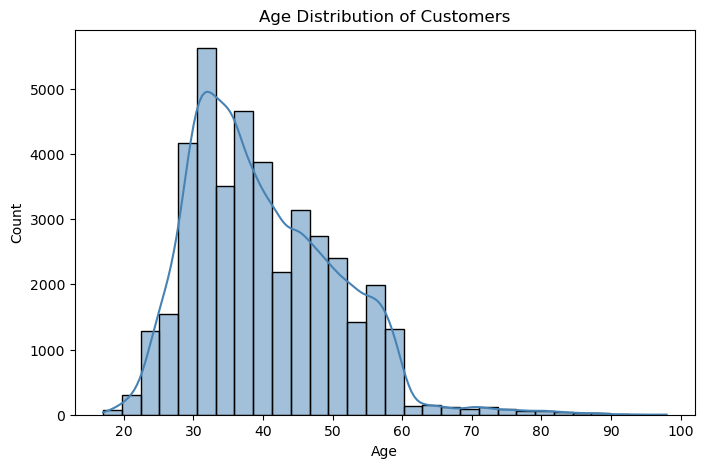

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64


In [3]:
# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

print(df['age'].describe())

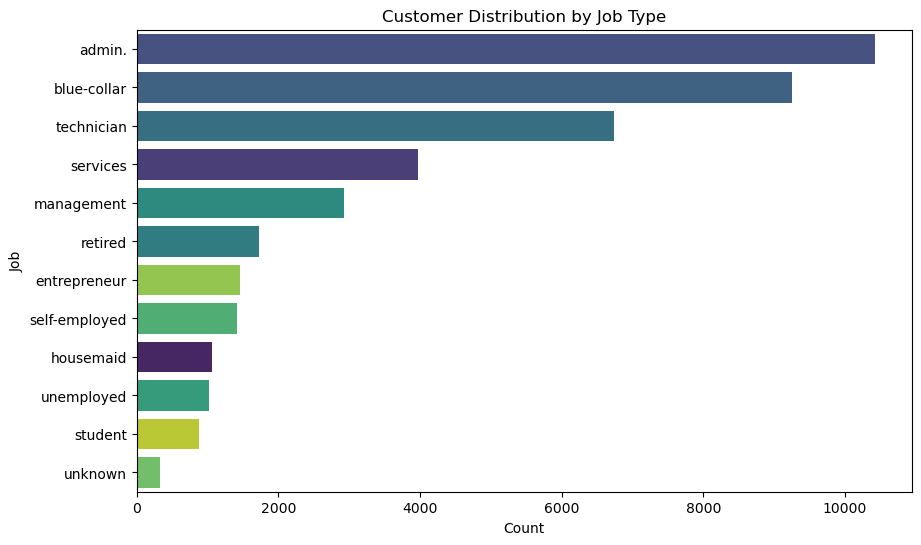

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


In [4]:
# Job distribution
plt.figure(figsize=(10, 6))
order = df['job'].value_counts().index
sns.countplot(data=df, y='job', order=order, palette='viridis', hue='job', legend=False)
plt.title('Customer Distribution by Job Type')
plt.xlabel('Count')
plt.ylabel('Job')
plt.show()

print(df['job'].value_counts())


## Balance & Deposit Trends

Average duration by deposit subscription:

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


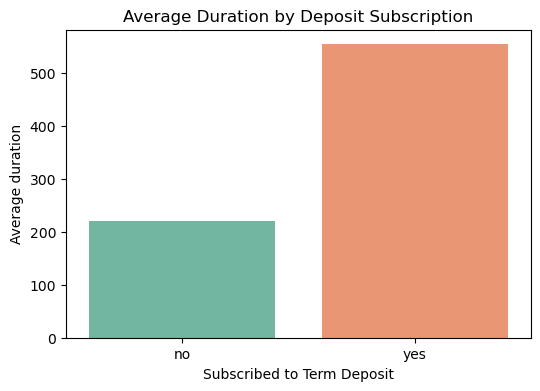

In [5]:
# Average balance by deposit subscription
balance_like_col = 'balance' if 'balance' in df.columns else 'duration'

avg_by_deposit = df.groupby('y')[balance_like_col].mean()
print(f"Average {balance_like_col} by deposit subscription:\n")
print(avg_by_deposit)

plt.figure(figsize=(6, 4))
sns.barplot(x=avg_by_deposit.index, y=avg_by_deposit.values, hue=avg_by_deposit.index,
            palette='Set2', legend=False)
plt.title(f'Average {balance_like_col.capitalize()} by Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel(f'Average {balance_like_col}')
plt.show()



## Campaign Effectiveness

Subscription rate (%) by contact method:

y                 no        yes
contact                        
cellular   85.262393  14.737607
telephone  94.768679   5.231321


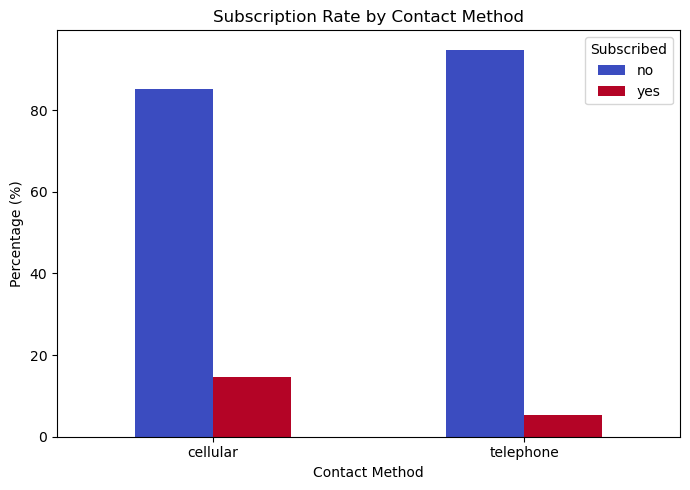

In [6]:
# Contact method analysis
contact_crosstab = pd.crosstab(df['contact'], df['y'], normalize='index') * 100
print("Subscription rate (%) by contact method:\n")
print(contact_crosstab)

plt.figure(figsize=(7, 5))
contact_crosstab.plot(kind='bar', stacked=False, ax=plt.gca(), colormap='coolwarm')
plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()



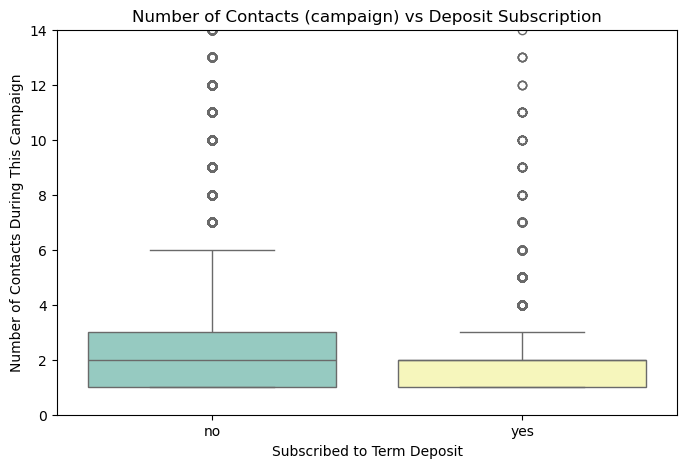

       count      mean       std  min  25%  50%  75%   max
y                                                         
no   36548.0  2.633085  2.873438  1.0  1.0  2.0  3.0  56.0
yes   4640.0  2.051724  1.666245  1.0  1.0  2.0  2.0  23.0


In [8]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='y', y='campaign', hue='y', palette='Set3', legend=False)
plt.title('Number of Contacts (campaign) vs Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Number of Contacts During This Campaign')
plt.ylim(0, df['campaign'].quantile(0.99))  # trim extreme outliers for readability
plt.show()

print(df.groupby('y')['campaign'].describe())



## Correlation Heatmap

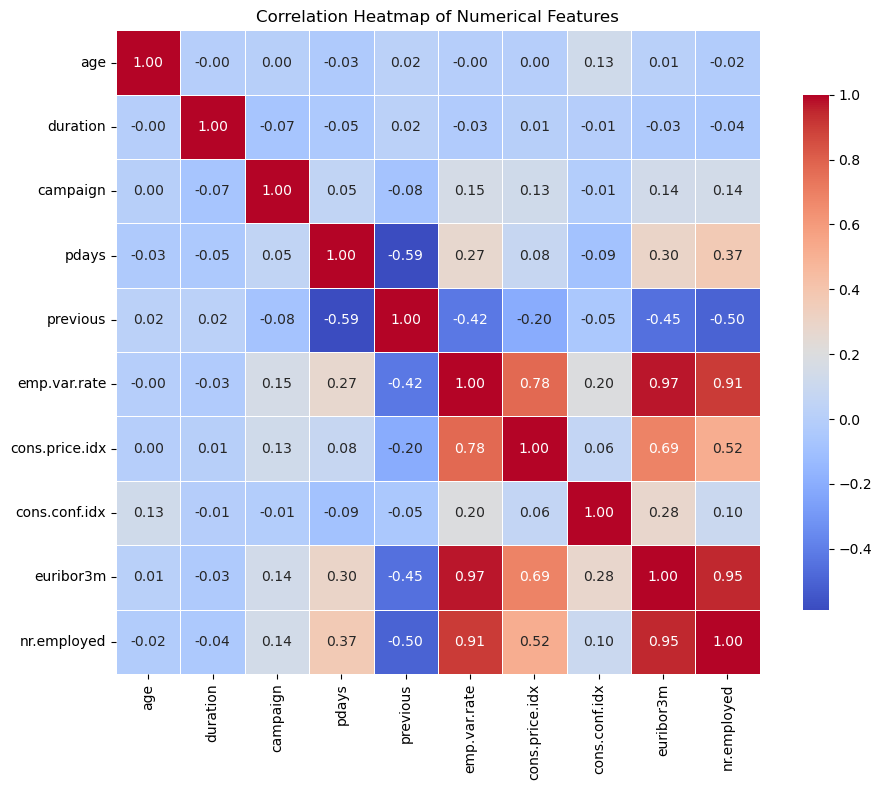

In [9]:
# Correlation of numerical variables
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


## Predictive Modeling (Logistic Regression)

Accuracy:  0.8527555231852392
Precision: 0.42643262777490964
Recall:    0.8900862068965517
F1 Score:  0.5766143106457242
ROC AUC:   0.9361368755601679

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      7310
           1       0.43      0.89      0.58       928

    accuracy                           0.85      8238
   macro avg       0.71      0.87      0.74      8238
weighted avg       0.92      0.85      0.87      8238



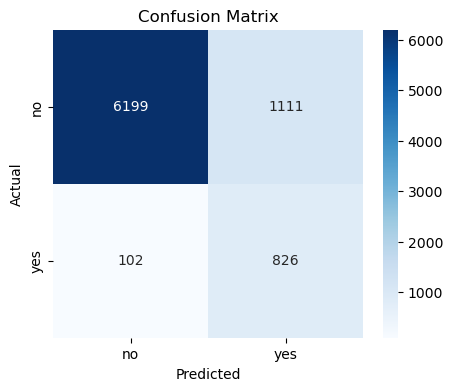

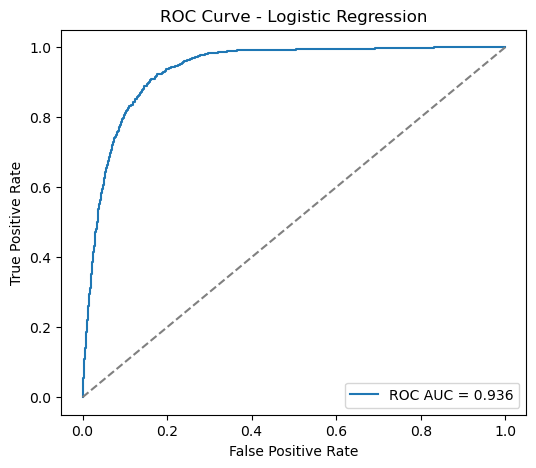

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Encode categorical variables
df_model = df.copy()

categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y')  # target handled separately

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Encode target: yes -> 1, no -> 0
df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

X = df_model.drop(columns=['y'])
y_target = df_model['y']

# Train/test split (stratified to preserve class imbalance ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target
)

# Fit logistic regression (class_weight='balanced' helps with the imbalanced target)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC AUC:  ", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


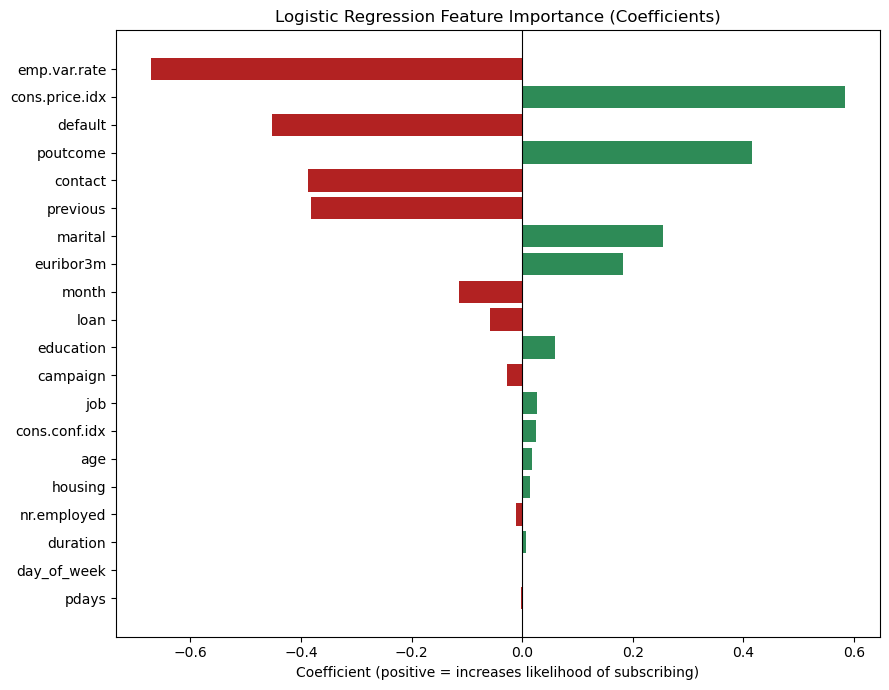

,feature,coefficient,abs_coefficient
0,emp.var.rate,-0.671599,0.671599
1,cons.price.idx,0.584255,0.584255
2,default,-0.453172,0.453172
3,poutcome,0.414839,0.414839
4,contact,-0.388073,0.388073
5,previous,-0.381157,0.381157
6,marital,0.254573,0.254573
7,euribor3m,0.181586,0.181586
8,month,-0.114347,0.114347
9,loan,-0.059083,0.059083


In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0]
})
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(9, 7))
colors = ['seagreen' if c > 0 else 'firebrick' for c in feature_importance['coefficient']]
plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Feature Importance (Coefficients)')
plt.xlabel('Coefficient (positive = increases likelihood of subscribing)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

feature_importance.reset_index(drop=True)

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.